In [62]:
% pip install pyodbc pandas

UsageError: Line magic function `%` not found.


In [ ]:
import pyodbc
import pandas as pd

In [ ]:
server = 'DESKTOP-MEA6VBT\\SQLEXPRESS'  # Jo SSMS mein nazar aa raha ho
database = 'Colabs_Ecosystem'

In [ ]:
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'

In [ ]:
try:
    conn = pyodbc.connect(conn_str)
    print("[INFO] Database connection established successfully.")
    
    # Executing SQL query to fetch data into a Pandas DataFrame
    query = "SELECT * FROM Bookings;"
    df = pd.read_sql(query, conn)
    
    print(f"[SUCCESS] Retrieved {len(df)} records from 'Bookings' table.\n")
    print("--- Initial Raw DataFrame ---")
    display(df)

except pyodbc.Error as db_error:
    print(f"[ERROR] Database connection failed. Details: {db_error}")
except Exception as general_error:
    print(f"[ERROR] An unexpected error occurred: {general_error}")

[INFO] Database connection established successfully.
[SUCCESS] Retrieved 5 records from 'Bookings' table.

--- Initial Raw DataFrame ---


C:\Users\JUST BUY PC\AppData\Local\Temp\ipykernel_8372\221682206.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,BookingID,MemberID,ResourceID,BookingDate,HoursUsed,AmountPaid,PaymentStatus
0,1001,1,101,2026-05-10,4.0,800.0,Paid
1,1002,2,103,2026-05-11,2.0,3000.0,Paid
2,1003,3,102,2026-05-12,5.0,NaN,Pending
3,1004,4,104,2026-05-12,NaN,0.0,None
4,1005,1,103,2026-05-13,3.0,4500.0,Paid


In [ ]:
print("---Missing Values Per Colomn---")
print(df.isnull().sum())

---Missing Values Per Colomn---
BookingID        0
MemberID         0
ResourceID       0
BookingDate      0
HoursUsed        1
AmountPaid       1
PaymentStatus    1
dtype: int64


In [ ]:
hours_median=df['HoursUsed'].median()
print(f"[INFO]Median of HoursUsed: {hours_median}")

[INFO]Median of HoursUsed: 3.5


In [ ]:
df['HoursUsed'] = df['HoursUsed'].fillna(hours_median)

In [ ]:
df['HoursUsed']

0    4.0
1    2.0
2    5.0
3    3.5
4    3.0
Name: HoursUsed, dtype: float64

In [ ]:
amount_median=df['AmountPaid'].median()
print(f"[INFO]Median of AmountPaid: {amount_median}")

[INFO]Median of AmountPaid: 1900.0


In [ ]:
df['AmountPaid']=df['AmountPaid'].fillna(amount_median)

In [ ]:
df['AmountPaid']

0     800.0
1    3000.0
2    1900.0
3       0.0
4    4500.0
Name: AmountPaid, dtype: float64

In [ ]:
df['PaymentStatus']=df['PaymentStatus'].fillna('Unknown')

In [ ]:
df['PaymentStatus']

0       Paid
1       Paid
2    Pending
3    Unknown
4       Paid
Name: PaymentStatus, dtype: object

In [ ]:
df.isnull().sum()

BookingID        0
MemberID         0
ResourceID       0
BookingDate      0
HoursUsed        0
AmountPaid       0
PaymentStatus    0
dtype: int64

In [ ]:
df

,BookingID,MemberID,ResourceID,BookingDate,HoursUsed,AmountPaid,PaymentStatus
0,1001,1,101,2026-05-10,4.0,800.0,Paid
1,1002,2,103,2026-05-11,2.0,3000.0,Paid
2,1003,3,102,2026-05-12,5.0,1900.0,Pending
3,1004,4,104,2026-05-12,3.5,0.0,Unknown
4,1005,1,103,2026-05-13,3.0,4500.0,Paid


In [ ]:
total_revenue=df['AmountPaid'].sum()
print(total_revenue)

10200.0


In [ ]:
total_hours=df['HoursUsed'].sum()
print(total_hours)

17.5


In [ ]:
amount_mean=df['AmountPaid'].mean()
print(amount_mean)

2040.0


In [ ]:
hours_mean = df['HoursUsed'].mean()
print(hours_mean)

3.5


In [ ]:
pending_df=df[df['PaymentStatus']=='Pending']
pending_df

,BookingID,MemberID,ResourceID,BookingDate,HoursUsed,AmountPaid,PaymentStatus
2,1003,3,102,2026-05-12,5.0,1900.0,Pending


In [ ]:
df

,BookingID,MemberID,ResourceID,BookingDate,HoursUsed,AmountPaid,PaymentStatus
0,1001,1,101,2026-05-10,4.0,800.0,Paid
1,1002,2,103,2026-05-11,2.0,3000.0,Paid
2,1003,3,102,2026-05-12,5.0,1900.0,Pending
3,1004,4,104,2026-05-12,3.5,0.0,Unknown
4,1005,1,103,2026-05-13,3.0,4500.0,Paid


In [ ]:
df.columns

Index(['BookingID', 'MemberID', 'ResourceID', 'BookingDate', 'HoursUsed',
       'AmountPaid', 'PaymentStatus'],
      dtype='object')

In [ ]:
try:
    conn = pyodbc.connect(conn_str)
    print("[INFO] Database connection established successfully.")
    
    # Executing SQL query to fetch data into a Pandas DataFrame
    query = "SELECT * FROM Members";
    df1 = pd.read_sql(query, conn)
    query = "SELECT * FROM Desks_Rooms;"
    df2 = pd.read_sql(query, conn)

    print(f"[SUCCESS] Retrieved {len(df1)} records from 'Members' table.\n")
    print(f"[SUCCESS] Retrieved {len(df2)} records from 'Desks_Rooms' table.\n")
    print("--- Initial Raw DataFrames ---")
    display(df1)
    display(df2)

except pyodbc.Error as db_error:
    print(f"[ERROR] Database connection failed. Details: {db_error}")
except Exception as general_error:
    print(f"[ERROR] An unexpected error occurred: {general_error}")

[INFO] Database connection established successfully.
[SUCCESS] Retrieved 4 records from 'Members' table.

[SUCCESS] Retrieved 4 records from 'Desks_Rooms' table.

--- Initial Raw DataFrames ---


C:\Users\JUST BUY PC\AppData\Local\Temp\ipykernel_8372\2551758256.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql(query, conn)
C:\Users\JUST BUY PC\AppData\Local\Temp\ipykernel_8372\2551758256.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(query, conn)


,MemberID,FullName,Email,JoinDate,MembershipType
0,1,Ahmed Ali,ahmed.ali@email.com,2026-01-15,Hot Desk
1,2,Fatima Khan,None,2026-02-01,Private Office
2,3,Zainab Hassan,zainab@email.com,2026-03-10,Dedicated Desk
3,4,Bilal Siddiqui,bilal.siddique@email.com,None,Hot Desk


,ResourceID,ResourceName,ResourceType,HourlyRate
0,101,Desk-A1,Desk,200.0
1,102,Desk-A2,Desk,200.0
2,103,Chinar-Room,Meeting Room,1500.0
3,104,Shahkar-Cabin,Cabin,800.0


In [ ]:
name_df=df1[df1['FullName']=='Bilal Siddiqui']
print(name_df)

   MemberID        FullName                     Email JoinDate MembershipType
3         4  Bilal Siddiqui  bilal.siddique@email.com     None       Hot Desk


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
status_summary=df.groupby('PaymentStatus')['AmountPaid'].sum()

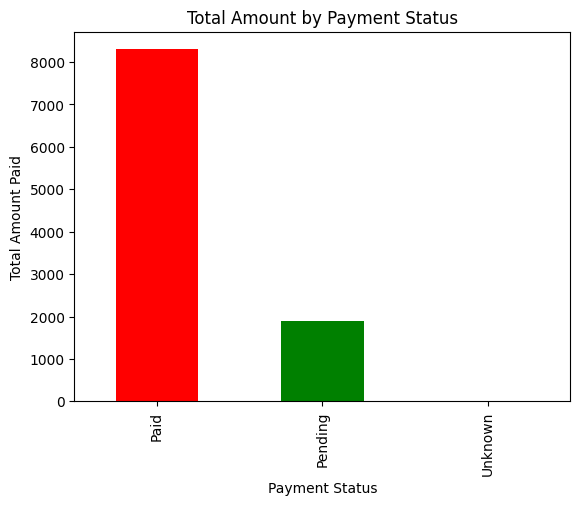

In [ ]:
status_summary.plot(kind='bar',color=['red','green'])
plt.title('Total Amount by Payment Status')
plt.xlabel('Payment Status')
plt.ylabel('Total Amount Paid')
plt.show()